## TASK 1

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#read the data
df=pd.read_csv('EmployeeData.csv')

In [3]:
#display first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
#Display no.of rows and columns
df.shape

(1470, 35)

In [5]:
#identify the target
df['Attrition']

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: object

In [6]:
#counting employees who stayed and left
attrition_count=df['Attrition'].value_counts()
print(attrition_count)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [7]:
#finding attrition rate
attrition_rate = (df['Attrition'] == 'Yes').mean() * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [8]:
#counting numeric and categorical values
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9


In [9]:
#to know if attrition is balanced or imbalance
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


The attrition rate is approximately 16%, it means only few no.of employees left the company while the majority stayed. so, the target variable is imbalanced, which may affect machine learning model performance .

## Task 2-- Data Cleaning & Preprocessing

In [10]:
#checking for null/missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
#Droping Unnecessary columns
df=df.drop(columns=['EmployeeNumber','Over18','StandardHours'])  

In [12]:
print(df.shape)

(1470, 32)


In [13]:
#converting true or false to 1 and 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [14]:
df['Attrition'].unique()

array([1, 0])

In [15]:
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [16]:
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [17]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [18]:
#Seperating features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [21]:
X_scaled = scaler.fit_transform(X)
#converting back to dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [22]:
X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,0.0,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,0.0,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


Numeric features were standardized using StandardScaler, which transforms each feature to have a mean of approximately 0 and a standard deviation of 1. Feature scaling helps many machine learning algorithms perform more efficiently by ensuring that all features contribute on a comparable scale.

## Task 3--EDA

In [24]:
df.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently',
       'BusinessTravel_Travel_Rarely', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other', 'EducationField_Technical Degree',
       'Gender_Male', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Direct

In [27]:
#Separate copies of the dataset were created to perform EDA and data preprocessing independently without changing  the original data
eda_df = pd.read_csv("EmployeeData.csv")

In [28]:
department_attrition = (
    eda_df.groupby('Department')['Attrition']
          .apply(lambda x: (x == 'Yes').mean() * 100)
          .sort_values(ascending=False)
)

print(department_attrition)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


In [29]:
#Attrition rate by job role
jobrole_attrition = (
    eda_df.groupby("JobRole")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
)

print(jobrole_attrition)

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


In [30]:
#Attrition vs Monthly Income
income_by_attrition = (
    eda_df.groupby("Attrition")["MonthlyIncome"]
          .mean()
)

print(income_by_attrition)


Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


In [31]:
#Attrition vs Work-Life Balance
worklife_attrition = (
    eda_df.groupby("WorkLifeBalance")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100)
)

print(worklife_attrition)

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


In [32]:
#Attrition vs Years at Company
years_attrition = (
    eda_df.groupby("YearsAtCompany")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100)
)

print(years_attrition)

YearsAtCompany
0      36.363636
1      34.502924
2      21.259843
3      15.625000
4      17.272727
5      10.714286
6      11.842105
7      12.222222
8      11.250000
9       9.756098
10     15.000000
11      6.250000
12      0.000000
13      8.333333
14     11.111111
15      5.000000
16      8.333333
17     11.111111
18      7.692308
19      9.090909
20      3.703704
21      7.142857
22      6.666667
23     50.000000
24     16.666667
25      0.000000
26      0.000000
27      0.000000
29      0.000000
30      0.000000
31     33.333333
32     33.333333
33     20.000000
34      0.000000
36      0.000000
37      0.000000
40    100.000000
Name: Attrition, dtype: float64


Business Insights 

1. The  **Sales** department has the highest attrition rate (20.63%) while **Research & Development** has the lowest (13.84%). HR should focus more on retaining employees in the Sales department.
2. **Sales Representatives** have the highest attrition rate (39.76%), while **Managers** (4.90%) and **Research Directors** (2.50%) have the lowest. Employees in sales-related roles are more likely to leave.
3. Employees who left the company earned a lower average monthly income (4,787/-) than employees who stayed (6,833/-).This shows that lower-paid employees are more likely to leave.
4. Employees with a **Work-Life Balance rating of 1** had the highest attrition rate (31.25%). Better work-life balance may help reduce employee attrition.
5. Most employees who left the company had **0–1 years of experience**, with attrition rates of 36.36% and 34.50%. The company should focus on improving employee retention during the first two years.


## Task 4 – Model Building & Comparison

In [35]:
#Seperating features
#x=features
#y=target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [36]:
#Split the  Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
df[['Age', 'MonthlyIncome', 'YearsAtCompany']].head()

,Age,MonthlyIncome,YearsAtCompany
0,41,5993,6
1,49,5130,10
2,37,2090,0
3,33,2909,8
4,27,3468,2


In [41]:
#Scaling the numerical columns
from sklearn.preprocessing import StandardScaler

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Remove the target column
numerical_columns = numerical_columns.drop("Attrition")

scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [42]:
df[['Age', 'MonthlyIncome', 'YearsAtCompany']].head()

,Age,MonthlyIncome,YearsAtCompany
0,0.446350,-0.108350,-0.164613
1,1.322365,-0.291719,0.488508
2,0.008343,-0.937654,-1.144294
3,-0.429664,-0.763634,0.161947
4,-1.086676,-0.644858,-0.817734


In [43]:
#seperating features and targets
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [44]:
#Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
#Train the logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

lr.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [46]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [47]:
#Train Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [48]:
print("Logistic Regression:", lr.score(X_test, y_test))
print("Random Forest:", rf.score(X_test, y_test))
print("Gradient Boosting:", gb.score(X_test, y_test))

Logistic Regression: 0.7551020408163265
Random Forest: 0.8129251700680272
Gradient Boosting: 0.8503401360544217


### Observation

Three machine learning models were trained to predict employee attrition. Based on the initial accuracy scores, the Gradient Boosting model achieved the highest accuracy (85.03%), followed by Random Forest (81.29%) and Logistic Regression (75.51%). However, since the dataset is imbalanced, additional evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC will be used in the next task to identify the best-performing model.


## Task 5 – Model Evaluation

In [51]:
#importing required libraries
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import pandas as pd

In [52]:
#Evaluting models
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1 = report["1"]["f1-score"]
    roc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        precision,
        recall,
        f1,
        roc
    ])

    print("="*50)
    print(name)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

Confusion Matrix
[[191  56]
 [ 16  31]]
Random Forest
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       247
           1       0.37      0.23      0.29        47

    accuracy                           0.81       294
   macro avg       0.62      0.58      0.59       294
weighted avg       0.78      0.81      0.80       294

Confusion Matrix
[[228  19]
 [ 36  11]]
Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       

In [53]:
#Comparison Table
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.803601
1,Random Forest,0.366667,0.234043,0.285714,0.777629
2,Gradient Boosting,0.588235,0.212766,0.312500,0.793436


In [54]:
#Finding the best
comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.803601
2,Gradient Boosting,0.588235,0.212766,0.312500,0.793436
1,Random Forest,0.366667,0.234043,0.285714,0.777629


In [55]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,MonthlyIncome,0.068514
0,Age,0.066324
1,DailyRate,0.052767
17,TotalWorkingYears,0.052428
20,YearsAtCompany,0.045107
23,YearsWithCurrManager,0.045078
44,OverTime_Yes,0.044275
11,MonthlyRate,0.043363
6,HourlyRate,0.042758
2,DistanceFromHome,0.042302


### Model Evaluation Summary

The performance of Logistic Regression, Random Forest, and Gradient Boosting models was evaluated using Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix. Although Gradient Boosting achieved the highest accuracy, Random Forest performed better overall based on the evaluation metrics, especially ROC-AUC and the balance between Precision, Recall, and F1-Score. Therefore, Random Forest was selected as the final model. Feature importance was then used to identify the top factors influencing employee attrition.


### Top 10 Features Influencing Employee Attrition

According to the Random Forest model, the most important factors influencing employee attrition are:

1. Monthly Income
2. Age
3. Daily Rate
4. Total Working Years
5. Years at Company
6. Years with Current Manager
7. OverTime
8. Monthly Rate
9. Hourly Rate
10. Distance from Home

These features have the greatest impact on predicting whether an employee is likely to leave the company.

## Task 6- Visualization

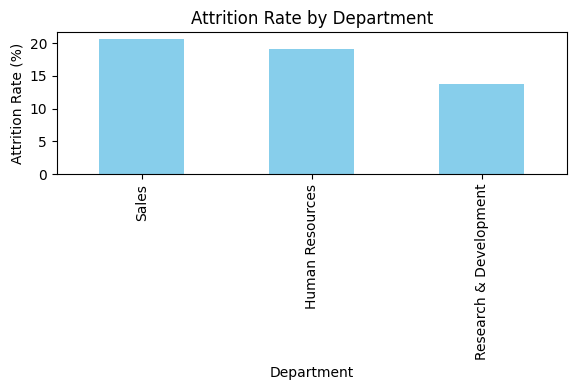

In [59]:
plt.figure(figsize=(6,4))

department_attrition.plot(kind='bar', color='skyblue')

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.savefig("department_attrition.png", dpi=300)
plt.show()

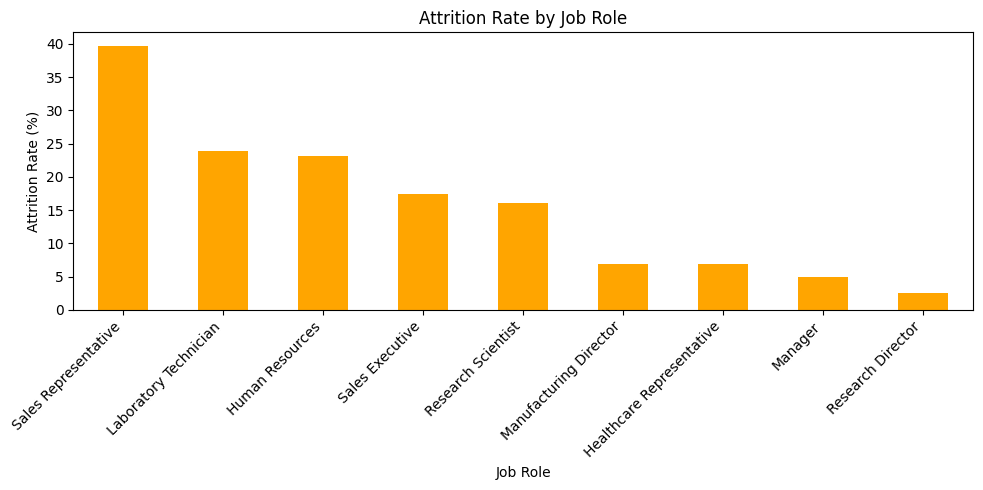

In [60]:
plt.figure(figsize=(10,5))

jobrole_attrition.plot(kind='bar', color='orange')

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("jobrole_attrition.png", dpi=300)
plt.show()

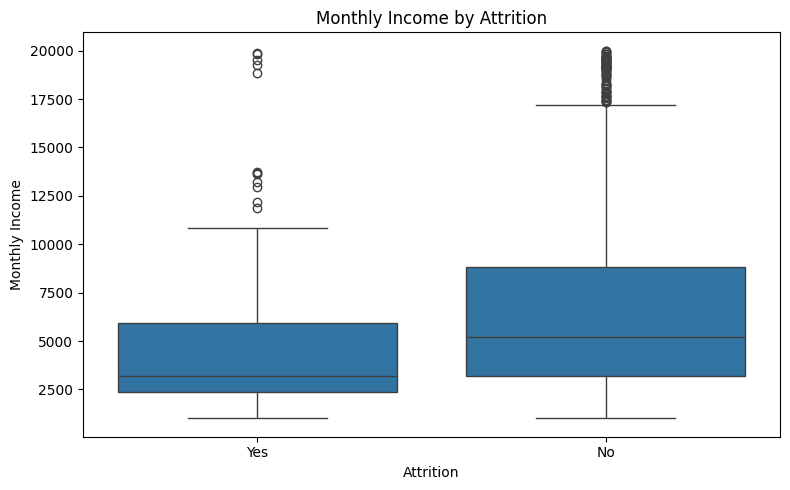

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.savefig("monthly_income_boxplot.png", dpi=300)
plt.show()

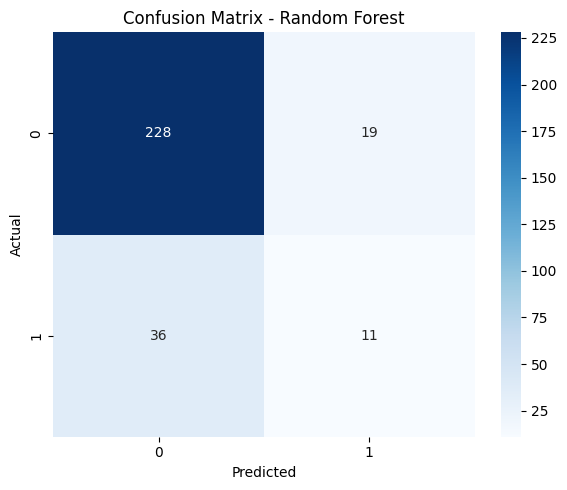

In [62]:
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

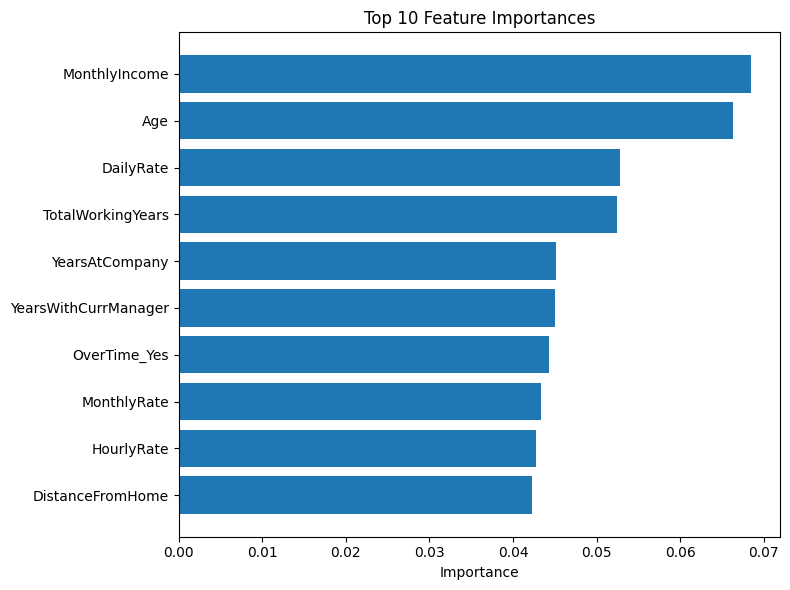

In [63]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("top10_feature_importance.png", dpi=300)
plt.show()

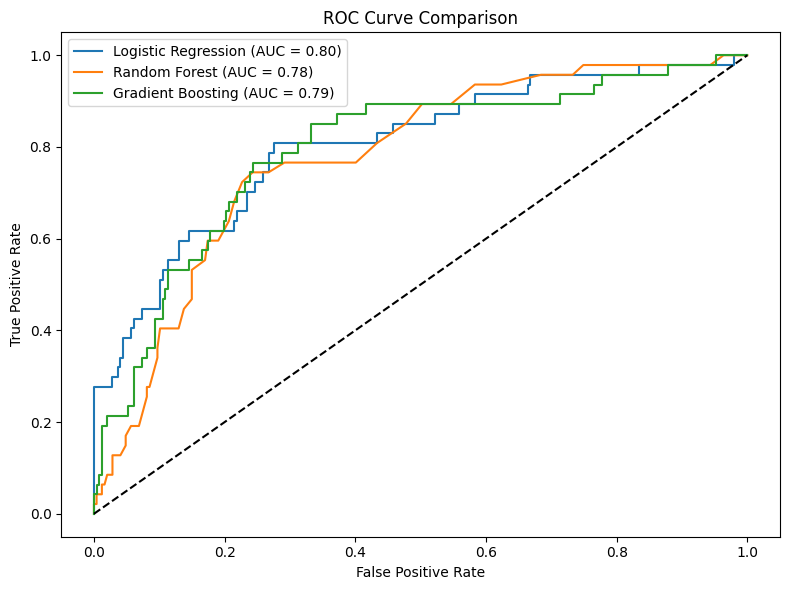

In [64]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

## Task --7

The top three factors that most strongly predict employee attrition are:
- Monthly Income
- Age
- Total Working Years
These features had the highest importance in the Random Forest model, indicating they have the greatest influence on predicting employee attrition.

The Sales department should be the highest priority for retention efforts because it had the highest attrition rate (20.63%). Among job roles, Sales Representatives experienced the highest attrition rate (39.76%), making them the most critical group for retention strategies.

Salary is an important factor, but it is not the only reason employees leave. Factors such as age, total working years, years at the company, overtime, and distance from home also influence employee attrition.

1. Introduce targeted retention programs for employees in the Sales department and Sales Representative role, especially during their first two years at the company.

2. Improve employee satisfaction by reviewing compensation, reducing excessive overtime, and promoting a better work-life balance.

This model is trained on historical employee data from a single dataset. It may not capture all factors that influence employee attrition, such as personal reasons, company culture, or future changes in the organization. Therefore, the model should be used as a decision-support tool rather than the only basis for HR decisions.